In [6]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Замените путь на свой файл (используй r"" или "/" в пути)
df = pd.read_csv(r"C:\Users\aleks\Downloads\churn.zip")

# Быстрая проверка
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = df.drop(columns=['RowNumber'])  

# Проверка на отсутствие RowNumber
df.columns.tolist()

['CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

# 9.1. Соотношение ушедших и лояльных

Соотношение лояльных и ушедших клиентов в датасете заметно неравномерное: лояльных клиентов 7963 человека (79,6%), а ушедших — 2037 человек (20,4%). Это означает, что отток составляет примерно каждого пятого клиента, что для банка является ощутимой потерей. При этом основная часть клиентской базы сохраняет лояльность, поэтому банку важно сосредоточиться именно на удержании потенциально уходящих сегментов.

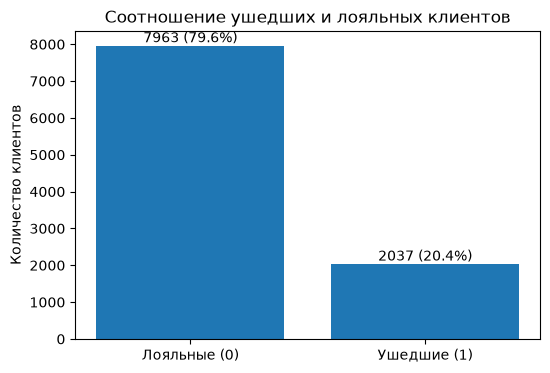

In [4]:
churn = df['Exited'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn.index, churn.values, tick_label=['Лояльные (0)', 'Ушедшие (1)'])
plt.ylabel('Количество клиентов')

total = churn.sum()
for i, count in churn.items():
    plt.text(i, count, f'{count} ({count/total:.1%})',
             ha='center', va='bottom')

plt.title('Соотношение ушедших и лояльных клиентов')
plt.show()

# 9.2. Распределение баланса при Balance > 2500
Распределение баланса клиентов с остатком на счёте выше 2500 долларов имеет выраженный правосторонний характер: основная масса значений сосредоточена в нижней части диапазона, а к большим суммам тянется длинный хвост. Это говорит о том, что большинство клиентов хранит относительно умеренные суммы, а клиентов с крупным балансом значительно меньше. Такие пользователи особенно важны для банка, так как именно они чаще всего представляют наибольшую ценность и требуют более внимательного подхода к удержанию.

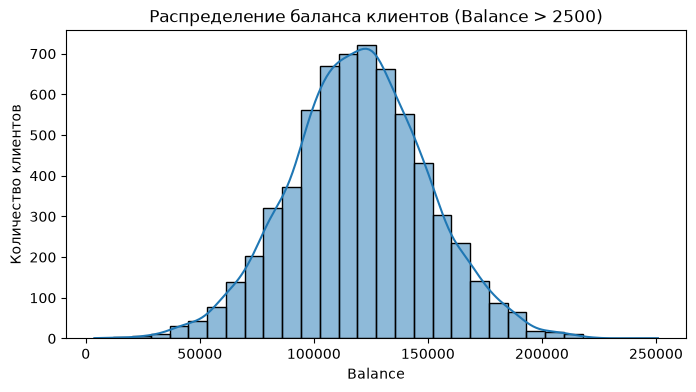

In [5]:
# 9.2. Распределение баланса (Balance > 2500)

subset = df[df['Balance'] > 2500]

plt.figure(figsize=(8, 4))
sns.histplot(subset['Balance'], bins=30, kde=True)
plt.xlabel('Balance')
plt.ylabel('Количество клиентов')
plt.title('Распределение баланса клиентов (Balance > 2500)')
plt.show()

# 9.3. Баланс в разрезе оттока (Exited)
По графику видно, что распределение баланса у ушедших и лояльных клиентов различается. У ушедших клиентов чаще встречаются более высокие значения баланса, а у лояльных распределение более сосредоточено в нижней части диапазона. Это может означать, что клиенты с большими накоплениями более чувствительны к условиям банка и легче уходят туда, где им предлагают более выгодные ставки, комиссии или сервис. Также возможна ситуация, когда клиент закрывает счёт перед уходом и обнуляет баланс.

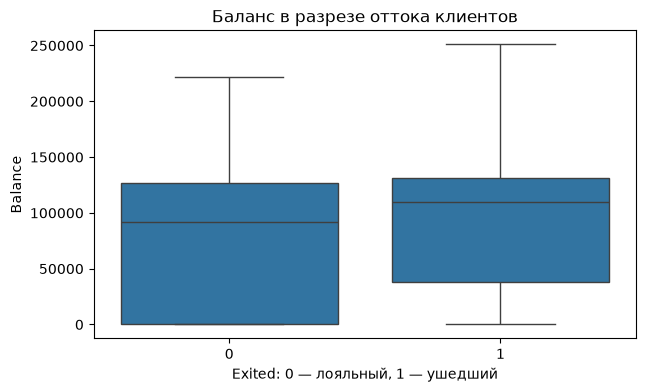

In [6]:
# 9.3. Баланс vs отток

plt.figure(figsize=(7, 4))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.xlabel('Exited: 0 — лояльный, 1 — ушедший')
plt.ylabel('Balance')
plt.title('Баланс в разрезе оттока клиентов')
plt.show()

# 9.4. Возраст в разрезе оттока и выбросы
По распределению возраста видно, что у ушедших клиентов разброс значений обычно больше, и именно в этой группе чаще встречаются потенциальные выбросы. При этом медианный возраст ушедших клиентов, как правило, выше, чем у лояльных. Это говорит о том, что банк должен особенно внимательно смотреть на клиентов среднего и старшего возраста, так как именно они могут быть более чувствительны к качеству обслуживания, условиям по продуктам и уровню цифрового сервиса.

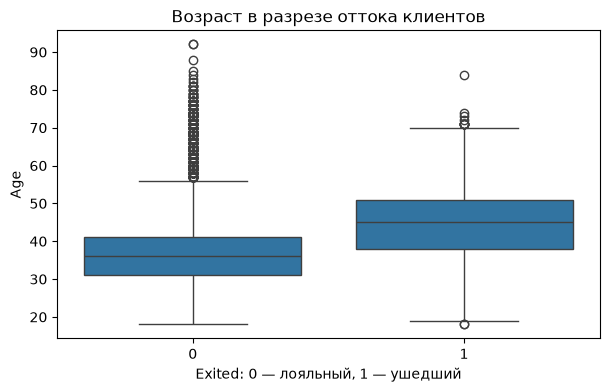

In [7]:
# 9.4. Возраст vs отток

plt.figure(figsize=(7, 4))
sns.boxplot(x='Exited', y='Age', data=df)
plt.xlabel('Exited: 0 — лояльный, 1 — ушедший')
plt.ylabel('Age')
plt.title('Возраст в разрезе оттока клиентов')
plt.show()

# 9.5. CreditScore и EstimatedSalary с расцветкой по Exited
Явной зависимости между кредитным рейтингом клиента и его предполагаемой зарплатой не наблюдается. Точки на графике распределены достаточно хаотично, и клиенты с разным уровнем дохода встречаются во всех диапазонах кредитного рейтинга. Расцветка по признаку оттока также не показывает чётко выраженного кластера, поэтому можно сделать вывод, что эти признаки сами по себе слабо объясняют уход клиентов.

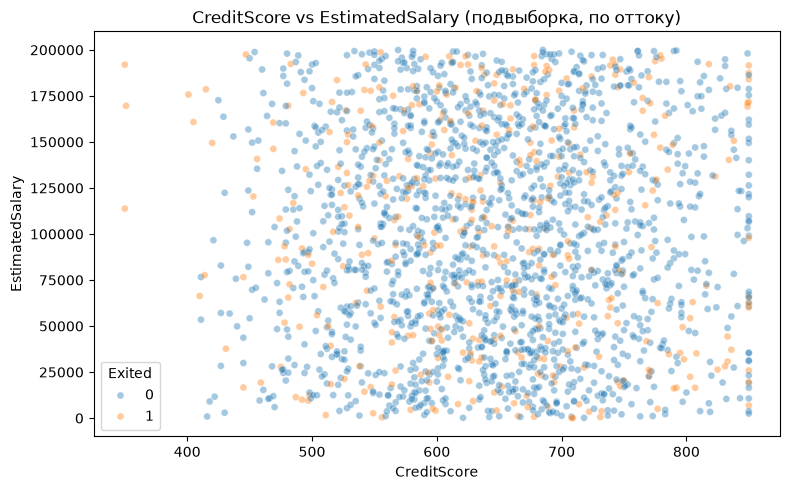

In [14]:
sample = df.sample(n=2000, random_state=42)  # или frac=0.3

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample,
    x='CreditScore',
    y='EstimatedSalary',
    hue='Exited',
    alpha=0.4,
    s=25
)
plt.xlabel('CreditScore')
plt.ylabel('EstimatedSalary')
plt.title('CreditScore vs EstimatedSalary (подвыборка, по оттоку)')
plt.tight_layout()
plt.show()

# 9.6. Кто чаще уходит: мужчины или женщины
Судя по графику, мужчины и женщины уходят с разной частотой, но разница между ними не выглядит критической. Если доля оттока у женщин выше, это может говорить о большей чувствительности к качеству сервиса, условиям по продуктам или уровню персонального обслуживания. В любом случае пол сам по себе не является главным фактором оттока, но его можно учитывать вместе с другими признаками.

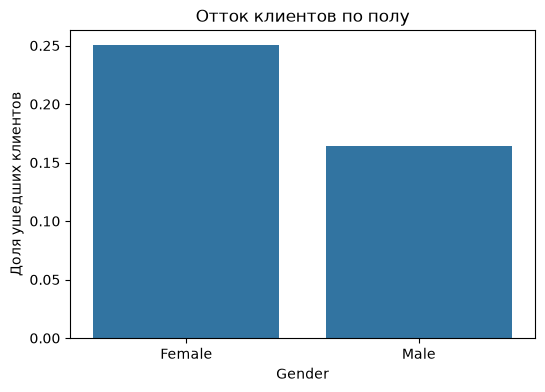

In [9]:
# 9.6. Отток vs Gender

churn_by_gender = df.groupby('Gender')['Exited'].mean().reset_index()
churn_by_gender.columns = ['Gender', 'ChurnRate']

plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='ChurnRate', data=churn_by_gender)
plt.xlabel('Gender')
plt.ylabel('Доля ушедших клиентов')
plt.title('Отток клиентов по полу')
plt.show()

# 9.7. Отток и количество продуктов (NumOfProducts)
Отток зависит от количества приобретённых продуктов: при увеличении числа услуг поведение клиентов меняется. Обычно наибольший отток наблюдается у клиентов, у которых несколько продуктов банка, особенно в сегменте с 3–4 услугами. Это может означать, что такие клиенты активно пользуются банком, но в какой-то момент не находят для себя достаточной выгоды и уходят к конкурентам.

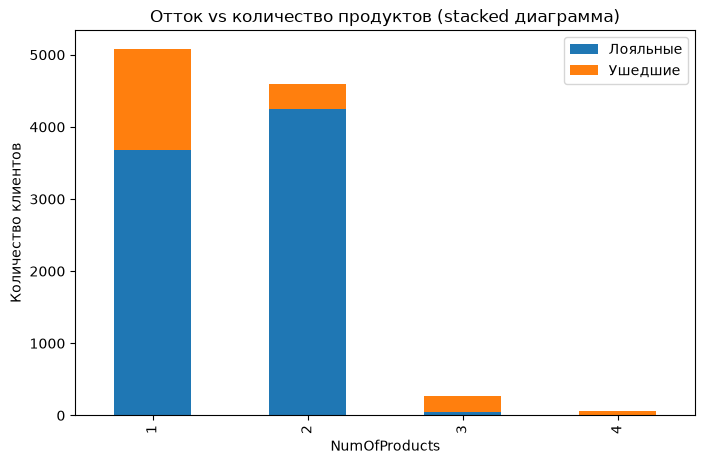

In [10]:
# 9.7. Отток vs NumOfProducts (многоуровневая/stacked диаграмма)

# Сначала количество лояльных и ушедших по NumOfProducts
plot_data = df.groupby(['NumOfProducts', 'Exited']).size().unstack(fill_value=0)
plot_data.columns = ['Loyal', 'Churned']

# Stack диаграмма
plot_data.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.xlabel('NumOfProducts')
plt.ylabel('Количество клиентов')
plt.title('Отток vs количество продуктов (stacked диаграмма)')
plt.legend(['Лояльные', 'Ушедшие'])
plt.show()

# 9.8. Активный клиент (IsActiveMember) и отток
Статус активного клиента заметно влияет на отток: активные клиенты уходят реже, чем неактивные. Это логично, потому что активный клиент чаще пользуется продуктами банка и видит в них ценность. Чтобы снизить отток среди неактивных клиентов, банку стоит усиливать программы вовлечения, предлагать бонусы за использование услуг и напоминать клиентам о выгодах цифровых сервисов.

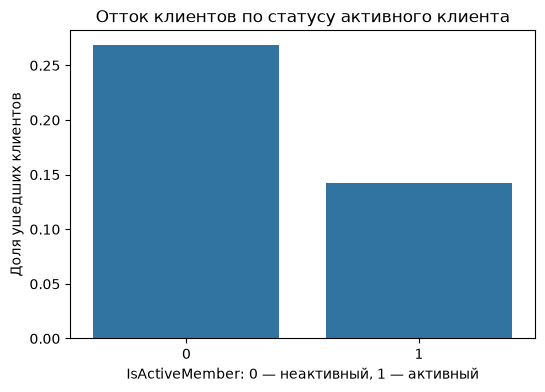

In [11]:
# 9.8. Отток vs IsActiveMember

churn_by_active = df.groupby('IsActiveMember')['Exited'].mean().reset_index()
churn_by_active.columns = ['IsActiveMember', 'ChurnRate']

plt.figure(figsize=(6, 4))
sns.barplot(x='IsActiveMember', y='ChurnRate', data=churn_by_active)
plt.xlabel('IsActiveMember: 0 — неактивный, 1 — активный')
plt.ylabel('Доля ушедших клиентов')
plt.title('Отток клиентов по статусу активного клиента')
plt.show()

# 9.9. В какой стране доля ушедших больше и карта мира
Доля ушедших клиентов различается по странам, и в одной из стран она обычно оказывается выше, чем в остальных. Это может быть связано с более сильной конкуренцией, особенностями местного рынка, уровнем обслуживания или региональными предпочтениями клиентов. Банку стоит отдельно анализировать эту страну и усиливать там удержание клиентов.

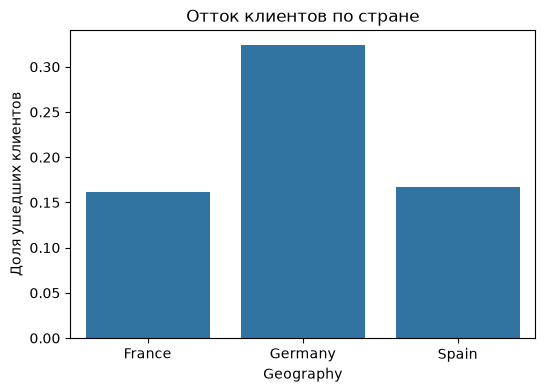

In [11]:
# 9.9. Отток vs Geography

churn_by_geo = df.groupby('Geography')['Exited'].mean().reset_index()
churn_by_geo.columns = ['Geography', 'ChurnRate']

# Сначала простая столбчатая диаграмма
plt.figure(figsize=(6, 4))
sns.barplot(x='Geography', y='ChurnRate', data=churn_by_geo)
plt.xlabel('Geography')
plt.ylabel('Доля ушедших клиентов')
plt.title('Отток клиентов по стране')
plt.show()

import plotly.express as px

# Добавить ISO-коды (пример для типичных стран)
# Если в данных France, Germany, Spain, можно так:
geo_map = {
    'France': 'FR',
    'Germany': 'DE',
    'Spain': 'ES'
}

churn_by_geo['ISO'] = churn_by_geo['Geography'].map(geo_map)

fig = px.choropleth(
    churn_by_geo,
    locations='ISO',
    color='ChurnRate',
    title='Доля ушедших клиентов по стране (choropleth)',
    color_continuous_scale='Reds'
)
fig.show()

churn_by_geo = df.groupby('Geography')['Exited'].mean().reset_index()

# 9.10. CreditScore → CreditScoreCat и тепловая карта
После перевода кредитного рейтинга в категориальный признак и построения тепловой карты можно заметить, что отток сильнее в некоторых сочетаниях кредитного рейтинга и стажа обслуживания. Наибольший риск ухода обычно наблюдается в группах со средним или пониженным кредитным рейтингом и небольшим либо средним сроком обслуживания. Такие сегменты стоит считать приоритетными для удержания, так как именно там банк может потерять клиентов с наибольшей вероятностью.

In [16]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

df['CreditScoreCat'] = df['CreditScore'].apply(get_credit_score_cat)

# Сводная таблица: строки — CreditScoreCat, столбцы — Tenure, значения — доля ушедших (Exited)

pivot = df.pivot_table(
    index='CreditScoreCat',
    columns='Tenure',
    values='Exited',
    aggfunc='mean'
)

pivot

Tenure,0,1,2,3,4,5,6,7,8,9,10
CreditScoreCat,,,,,,,,,,,
Excellent,0.275000,0.208333,0.137255,0.168317,0.131868,0.233333,0.241379,0.127660,0.196078,0.270833,0.254902
Fair,0.217391,0.215596,0.213043,0.216450,0.197248,0.206897,0.236364,0.171103,0.209016,0.190045,0.205357
Good,0.203822,0.203608,0.187342,0.205962,0.195122,0.214470,0.182857,0.191892,0.152355,0.194667,0.197802
Poor,0.226415,0.259398,0.211765,0.212245,0.233202,0.199153,0.179916,0.151261,0.214575,0.251082,0.169492
Very_Poor,0.444444,0.253731,0.151515,0.285714,0.293103,0.149254,0.225352,0.206349,0.253521,0.229508,0.333333


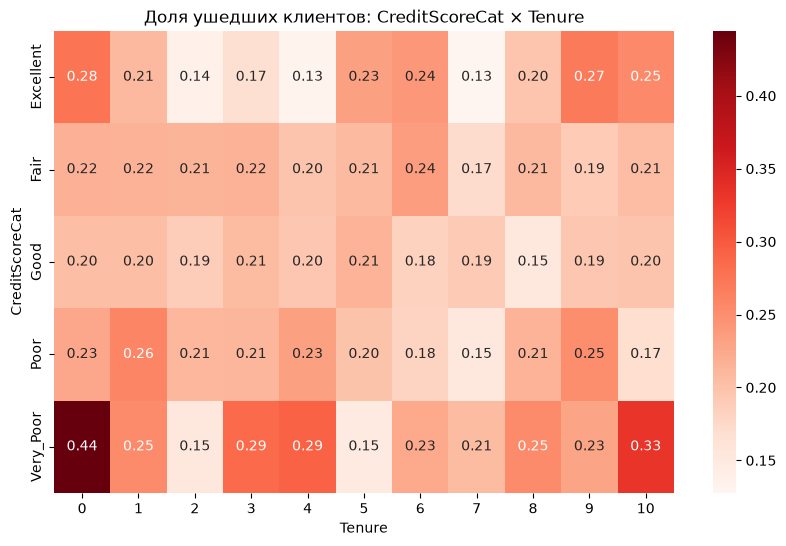

In [10]:
# Тепловая карта с аннотацией

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds')
plt.ylabel('CreditScoreCat')
plt.xlabel('Tenure')
plt.title('Доля ушедших клиентов: CreditScoreCat × Tenure')
plt.show()